# Phase 6: Deep Dive into Test Predictions & Model Confidence

In this notebook, we'll dive deep into our CNN's "confidence". Softmax confidence means the probability the model assigns to its prediction.
- **A 95% confidence does NOT mean the model is right 95% of the time.** It just means the model's internal math assigned 95% probability to that class based on the features it saw.
- **When confidence is low (e.g. 50%)**, it typically means the model sees features belonging to two different digits (like a loop for an 8 and a curve for a 3) and cannot make a definitive decision.

Let's load the confidence report our analysis script generated and see how certain our model really is!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the confidence report
report = pd.read_csv('../model/confidence_report.csv')

# Load the raw test images so we can display them
test_df = pd.read_csv('../data/digi_rec_test.csv')
test_pixels = test_df.values

print(f"Loaded {len(report)} predictions and images.")

Loaded 28000 predictions and images.


## Confidence Histogram
What does the overall confidence distribution look like? 
A good model should be heavily skewed toward high confidence (mostly 95%+). If the model were guessing randomly, confidence would be spread evenly across all bins.

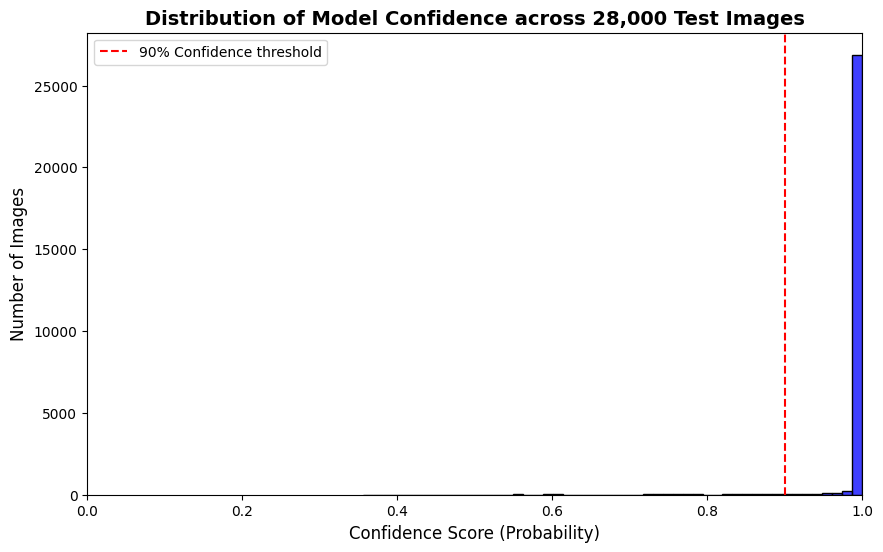

98.14% of predictions have > 90% confidence!


In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(report['Confidence'], bins=50, kde=False, color='blue')
plt.title('Distribution of Model Confidence across 28,000 Test Images', fontsize=14, fontweight='bold')
plt.xlabel('Confidence Score (Probability)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xlim(0, 1)

# Add a line to show where 90% confidence is
plt.axvline(0.90, color='red', linestyle='--', label='90% Confidence threshold')
plt.legend()
plt.show()

# Let's see the percentage of images > 90% confidence
high_conf = len(report[report['Confidence'] > 0.90]) / len(report) * 100
print(f"{high_conf:.2f}% of predictions have > 90% confidence!")

## Average Confidence per Digit
Which digits are the hardest for the model? Typically, digits that share visual features with others (like 4/9 or 3/8) have lower average confidences because the model gets "torn" between them more often.

/var/folders/qy/6j59jch50gz921514blf2qw80000gn/T/ipykernel_20143/4153359569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PredictedLabel', y='Confidence', data=avg_conf_per_digit, palette='viridis')


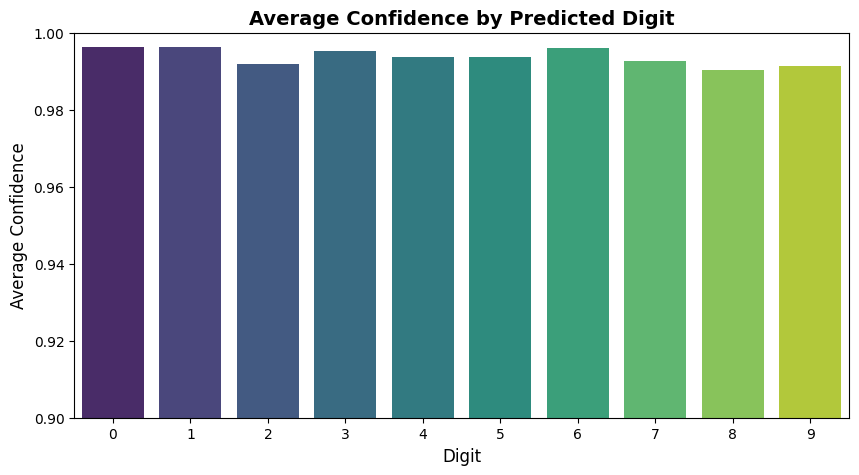

In [3]:
avg_conf_per_digit = report.groupby('PredictedLabel')['Confidence'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='PredictedLabel', y='Confidence', data=avg_conf_per_digit, palette='viridis')
plt.title('Average Confidence by Predicted Digit', fontsize=14, fontweight='bold')
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Average Confidence', fontsize=12)
plt.ylim(0.9, 1.0) # Zoom in to see the differences
plt.show()

## The "Perfect" Digits
Let's look at the absolute most confident prediction for each digit (the images where the model was closest to 100% sure).

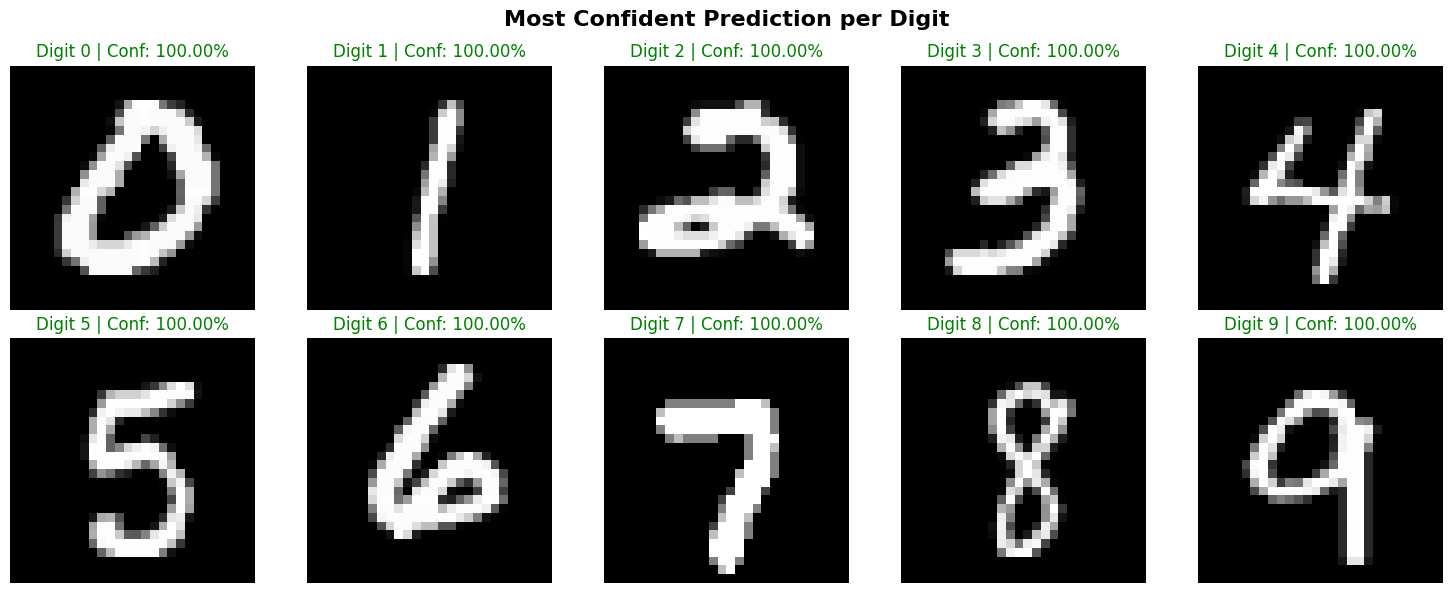

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Most Confident Prediction per Digit', fontsize=16, fontweight='bold')

for digit in range(10):
    # Find the row with the highest confidence for this digit
    top_row = report[report['PredictedLabel'] == digit].nlargest(1, 'Confidence').iloc[0]
    
    # ImageId is 1-indexed, so we subtract 1 to get the array index
    idx = int(top_row['ImageId']) - 1
    conf = top_row['Confidence']
    
    # Reshape the 784 pixels back into 28x28
    img = test_pixels[idx].reshape(28, 28)
    
    r = digit // 5
    c = digit % 5
    ax = axes[r, c]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Digit {digit} | Conf: {conf*100:.2f}%", color='green')
    ax.axis('off')

plt.tight_layout()
plt.show()

## The 20 Most Uncertain Predictions
Now let's look at where the model struggled the most. These are the 20 images with the lowest overall confidence scores.
Notice how messy, ambiguous, or poorly written these digits are! This is why human handwriting is hard.

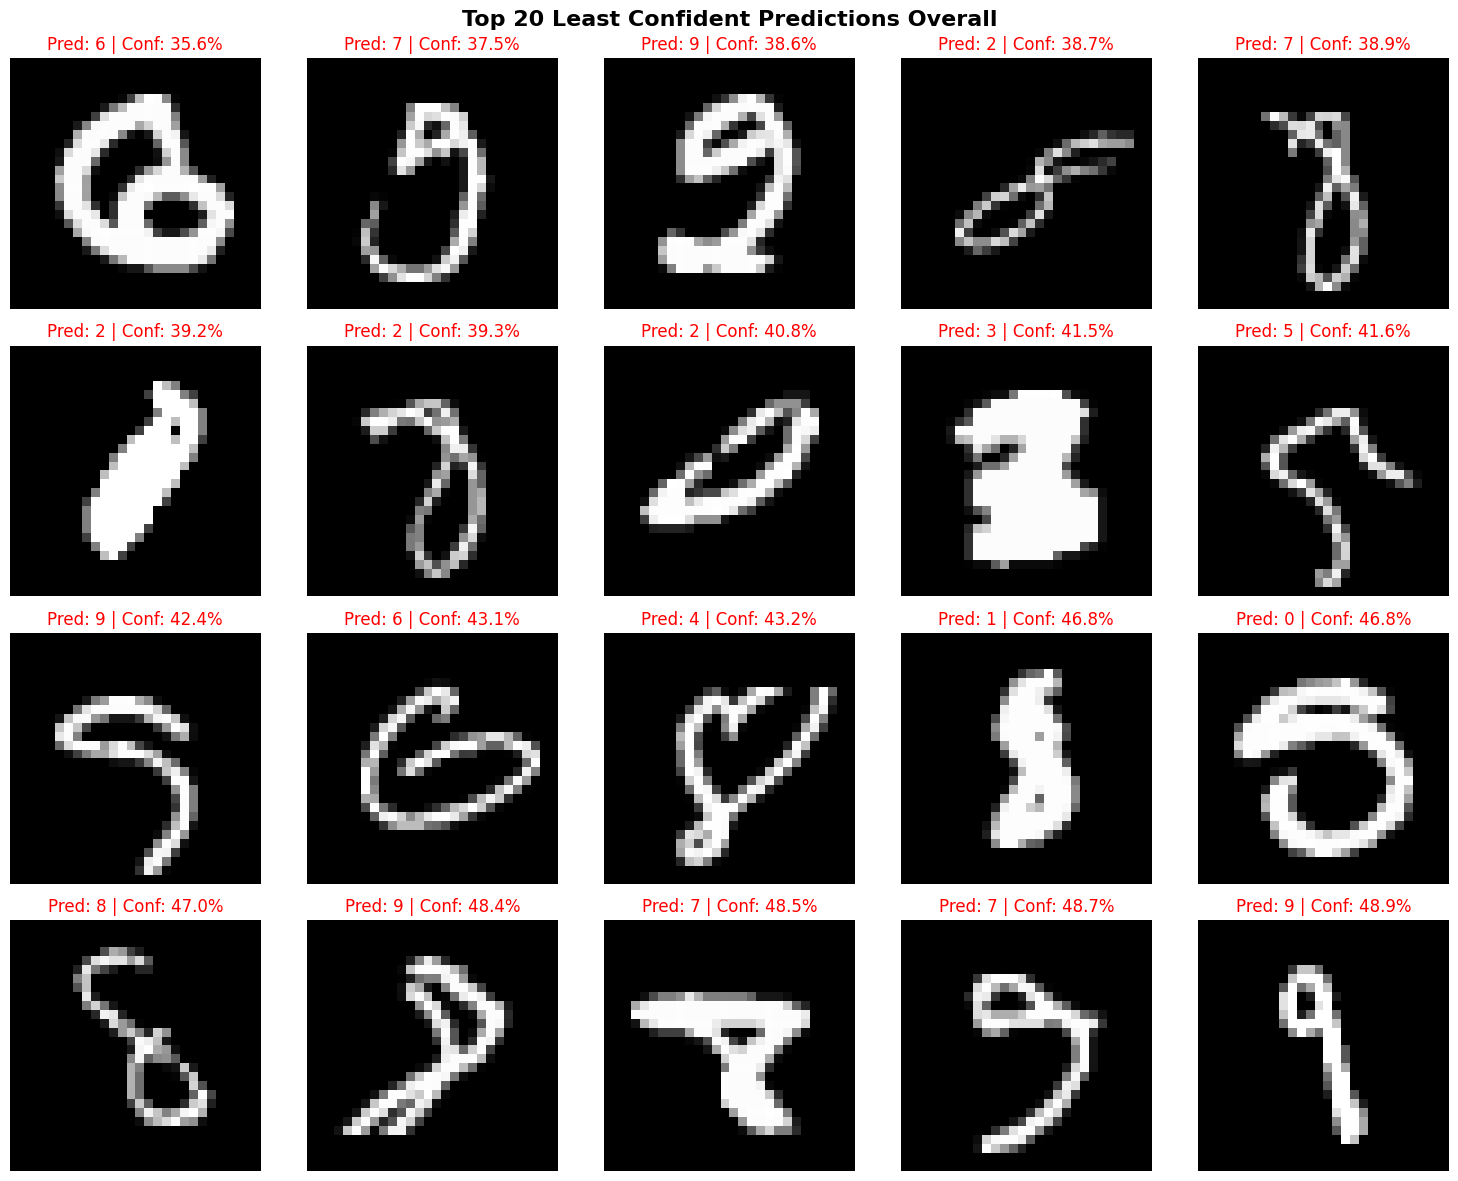

In [5]:
bottom_20 = report.nsmallest(20, 'Confidence')

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Top 20 Least Confident Predictions Overall', fontsize=16, fontweight='bold')

for i, (index, row) in enumerate(bottom_20.iterrows()):
    idx = int(row['ImageId']) - 1
    pred = int(row['PredictedLabel'])
    conf = row['Confidence']
    
    img = test_pixels[idx].reshape(28, 28)
    
    r = i // 5
    c = i % 5
    ax = axes[r, c]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {pred} | Conf: {conf*100:.1f}%", color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()